11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


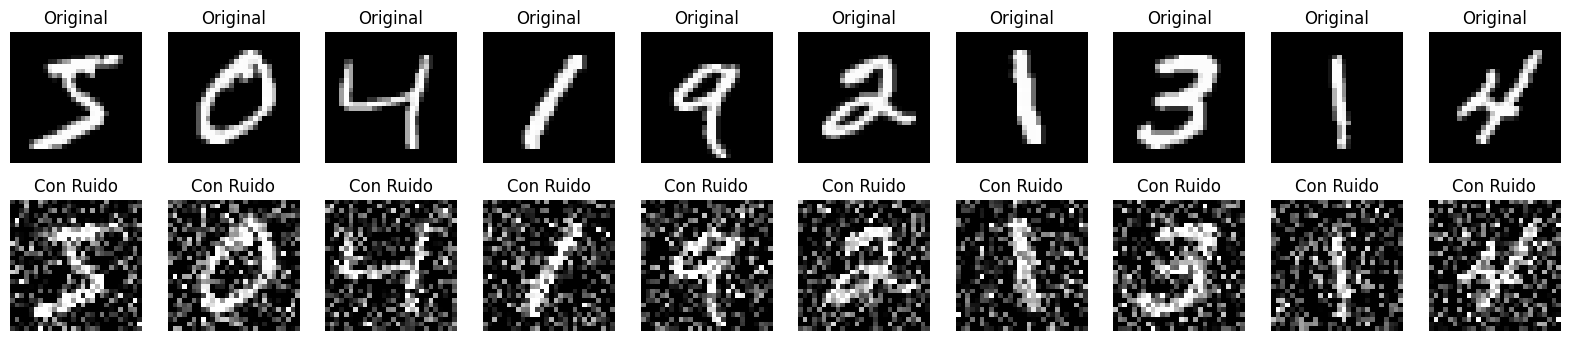

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 247ms/step - loss: 0.1622 - val_loss: 0.1058
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - loss: 0.1032 - val_loss: 0.0989
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0986 - val_loss: 0.0958
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 239ms/step - loss: 0.0961 - val_loss: 0.0940
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 245ms/step - loss: 0.0945 - val_loss: 0.0927
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - loss: 0.0932 - val_loss: 0.0918
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0923 - val_loss: 0.0911
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 242ms/step - loss: 0.0915 - val_loss: 0.0905
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 245ms/step - loss: 0.0909 - val_loss: 0.0899
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 241ms/step - loss: 0.0903 - val_loss: 0.0893
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 241ms/step - loss: 0.0899 - val_loss: 0.0888
Epoch 12

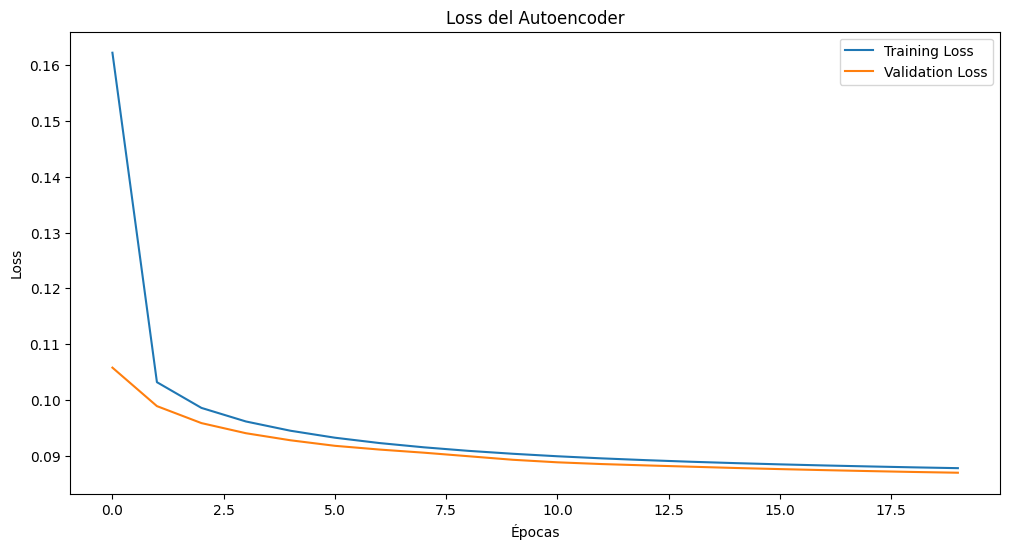

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


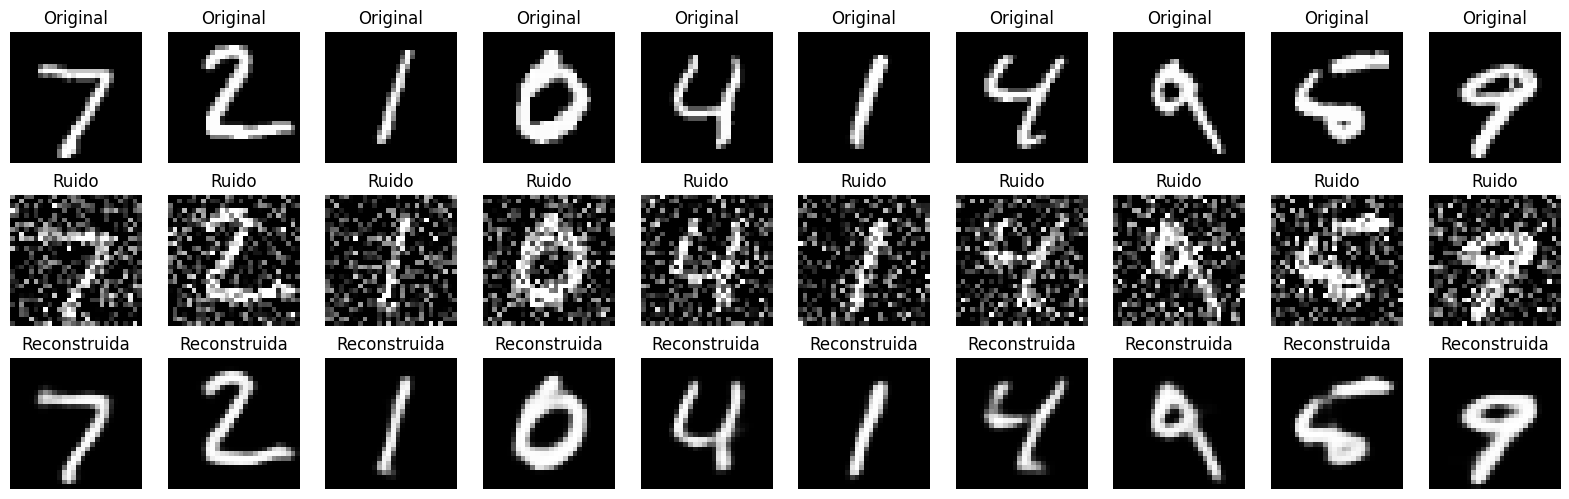


ERROR CUADRÁTICO MEDIO DEL MODELO
MSE: 0.008203

ANÁLISIS AUTOMÁTICO DEL MODELO
El modelo presenta una excelente capacidad de reconstrucción.

El Autoencoder logró aprender patrones relevantes del dataset.
La reducción del ruido evidencia aprendizaje efectivo.
Las imágenes reconstruidas conservan la estructura principal.


In [1]:
# ============================================================
# SEMANA 13 - ACTIVIDAD 13
# AUTOENCODER DENOISING CON MNIST
# TENSORFLOW / KERAS
# ============================================================

# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# TensorFlow y Keras para Deep Learning
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping

# Librerías numéricas
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt

# Métricas
from sklearn.metrics import mean_squared_error

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

# Semilla aleatoria para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# CARGA DEL DATASET MNIST
# ============================================================

# Cargar dataset MNIST desde TensorFlow
# x_train y x_test contienen imágenes
# y_train y y_test contienen etiquetas
# Las etiquetas no se usarán porque el autoencoder
# trabaja en aprendizaje no supervisado

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# ============================================================
# NORMALIZACIÓN DE DATOS
# ============================================================

# Convertir valores enteros a flotantes
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Normalizar valores al rango [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# ============================================================
# AJUSTE DE DIMENSIONES
# ============================================================

# Agregar canal adicional para trabajar con CNN
# Forma final:
# (numero_imagenes, 28, 28, 1)

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# ============================================================
# GENERACIÓN DE RUIDO ARTIFICIAL
# ============================================================

# Nivel de ruido gaussiano
noise_factor = 0.4

# Generar ruido aleatorio para entrenamiento
noise_train = noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Generar ruido aleatorio para prueba
noise_test = noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Agregar ruido a imágenes originales
x_train_noisy = x_train + noise_train
x_test_noisy = x_test + noise_test

# Limitar valores al rango [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ============================================================
# VISUALIZACIÓN DE IMÁGENES ORIGINALES Y RUIDOSAS
# ============================================================

# Crear figura
plt.figure(figsize=(20, 4))

# Mostrar imágenes originales
for i in range(10):

    ax = plt.subplot(2, 10, i + 1)

    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")

    plt.title("Original")
    plt.axis("off")

# Mostrar imágenes con ruido
for i in range(10):

    ax = plt.subplot(2, 10, i + 11)

    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")

    plt.title("Con Ruido")
    plt.axis("off")

plt.show()

# ============================================================
# CONSTRUCCIÓN DEL AUTOENCODER
# ============================================================

# Definir entrada
input_img = layers.Input(shape=(28, 28, 1))

# ============================================================
# ENCODER
# ============================================================

# Primera convolución
x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
)(input_img)

# Reducción dimensional
x = layers.MaxPooling2D((2, 2), padding='same')(x)

# Segunda convolución
x = layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
)(x)

# Segunda reducción dimensional
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# ============================================================
# DECODER
# ============================================================

# Reconstrucción parcial
x = layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
)(encoded)

# Upsampling
x = layers.UpSampling2D((2, 2))(x)

# Segunda reconstrucción
x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
)(x)

# Segundo Upsampling
x = layers.UpSampling2D((2, 2))(x)

# Capa de salida
decoded = layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    activation='sigmoid',
    padding='same'
)(x)

# ============================================================
# CREACIÓN DEL MODELO
# ============================================================

autoencoder = models.Model(input_img, decoded)

# ============================================================
# COMPILACIÓN DEL MODELO
# ============================================================

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# ============================================================
# RESUMEN DE LA ARQUITECTURA
# ============================================================

autoencoder.summary()

# ============================================================
# CALLBACK EARLY STOPPING
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

# ============================================================
# GRÁFICA DE PÉRDIDA
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss del Autoencoder')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ============================================================
# RECONSTRUCCIÓN DE IMÁGENES
# ============================================================

decoded_imgs = autoencoder.predict(x_test_noisy)

# ============================================================
# VISUALIZACIÓN COMPARATIVA
# ============================================================

n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    # Imagen original
    ax = plt.subplot(3, n, i + 1)

    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    plt.title("Original")
    plt.axis('off')

    # Imagen con ruido
    ax = plt.subplot(3, n, i + 1 + n)

    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')

    plt.title("Ruido")
    plt.axis('off')

    # Imagen reconstruida
    ax = plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')

    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

# ============================================================
# EVALUACIÓN DEL MODELO
# ============================================================

# Calcular error cuadrático medio
mse = mean_squared_error(
    x_test.flatten(),
    decoded_imgs.flatten()
)

print("\n===================================================")
print("ERROR CUADRÁTICO MEDIO DEL MODELO")
print("===================================================")
print(f"MSE: {mse:.6f}")

# ============================================================
# CONCLUSIONES AUTOMÁTICAS
# ============================================================

print("\n===================================================")
print("ANÁLISIS AUTOMÁTICO DEL MODELO")
print("===================================================")

if mse < 0.01:
    print("El modelo presenta una excelente capacidad de reconstrucción.")
elif mse < 0.03:
    print("El modelo presenta una buena capacidad de reconstrucción.")
else:
    print("El modelo puede mejorarse aumentando épocas o complejidad.")

print("\nEl Autoencoder logró aprender patrones relevantes del dataset.")
print("La reducción del ruido evidencia aprendizaje efectivo.")
print("Las imágenes reconstruidas conservan la estructura principal.")

# Semana 13 – Actividad 13: Implementación de un Autoencoder Denoising usando el dataset MNIST en Google Colab

# 1. Introducción

En el campo del Deep Learning, los Autoencoders representan una de las arquitecturas más importantes dentro del aprendizaje no supervisado. Estos modelos tienen como objetivo aprender representaciones compactas de los datos mediante un proceso de compresión y reconstrucción. Su funcionamiento se basa en dos componentes principales: un encoder, encargado de reducir dimensionalidad y extraer características relevantes, y un decoder, cuya función consiste en reconstruir la información original a partir de la representación comprimida.

Dentro de las múltiples variantes de autoencoders, los Denoising Autoencoders tienen una gran relevancia debido a su capacidad para eliminar ruido presente en imágenes o señales. En lugar de simplemente reconstruir la entrada original, este modelo aprende a restaurar información dañada o alterada artificialmente. Esto permite desarrollar modelos más robustos y con mayor capacidad de generalización.

En esta actividad se implementa un Autoencoder Denoising utilizando el dataset MNIST, compuesto por imágenes de dígitos escritos a mano. El propósito principal consiste en comprender cómo una red neuronal puede aprender patrones visuales relevantes para reconstruir imágenes afectadas por ruido artificial.

El desarrollo incluye la carga y preparación del dataset, la generación de ruido artificial, la implementación completa de la arquitectura encoder-decoder, el entrenamiento del modelo y el análisis visual de los resultados obtenidos. Además, se presentan métricas de desempeño y visualizaciones comparativas entre imágenes originales, imágenes ruidosas e imágenes reconstruidas.

La actividad fue desarrollada en Google Colab utilizando TensorFlow/Keras, siguiendo buenas prácticas de programación, documentación y organización del código.

---

# 2. Objetivos

## Objetivo General

Implementar un modelo Autoencoder Denoising utilizando TensorFlow/Keras para reconstruir imágenes del dataset MNIST afectadas por ruido artificial.

## Objetivos Específicos

- Cargar y preprocesar correctamente el dataset MNIST.
- Aplicar ruido artificial sobre las imágenes originales.
- Diseñar una arquitectura encoder-decoder funcional.
- Entrenar el modelo utilizando imágenes ruidosas como entrada.
- Evaluar la capacidad de reconstrucción del modelo.
- Comparar visualmente imágenes originales, ruidosas y reconstruidas.
- Analizar el comportamiento del modelo y sus posibles aplicaciones reales.

---

# 3. Descripción del Dataset

El dataset MNIST es uno de los conjuntos de datos más utilizados en Deep Learning y Visión por Computador. Contiene imágenes en escala de grises de dígitos escritos a mano.

Características principales del dataset:

- 70,000 imágenes en total.
- 60,000 imágenes para entrenamiento.
- 10,000 imágenes para prueba.
- Resolución de 28x28 píxeles.
- Imágenes en escala de grises.
- 10 clases correspondientes a los dígitos del 0 al 9.

Este dataset resulta adecuado para Autoencoders debido a su simplicidad y tamaño moderado, permitiendo observar claramente el proceso de reconstrucción de imágenes.

---

# 4. Preprocesamiento del Dataset

Antes del entrenamiento del modelo, fue necesario aplicar varias etapas de preprocesamiento con el fin de garantizar que los datos fueran adecuados para el aprendizaje.

Inicialmente, las imágenes fueron normalizadas dividiendo cada píxel entre 255. Esto permite trabajar con valores en el rango [0,1], facilitando la estabilidad numérica durante el entrenamiento.

Posteriormente, las imágenes fueron redimensionadas agregando una dimensión adicional correspondiente al canal de color, requerida por TensorFlow/Keras para trabajar con capas convolucionales.

Finalmente, se añadió ruido gaussiano artificial sobre las imágenes originales. Este ruido tiene como propósito deteriorar parcialmente la información visual para que el modelo aprenda a reconstruir la imagen limpia.

---

# 5. Generación de Ruido Artificial

El proceso de denoising requiere modificar artificialmente las imágenes originales para generar un escenario de reconstrucción.

Se utilizó ruido gaussiano aleatorio mediante una distribución normal. Este ruido fue agregado pixel por pixel sobre las imágenes originales.

Posteriormente, los valores fueron limitados nuevamente al rango [0,1] utilizando la función `clip`, evitando valores inválidos.

El uso de ruido artificial permite simular problemas reales presentes en procesamiento de imágenes, como:

- Imágenes borrosas.
- Interferencias en sensores.
- Compresión con pérdida.
- Ruido electrónico.
- Transmisión de imágenes dañadas.

---

# 6. Arquitectura del Autoencoder

El modelo implementado corresponde a un Autoencoder Convolucional Denoising.

La arquitectura se divide en dos partes principales:

## Encoder

La fase encoder tiene como objetivo extraer características relevantes y reducir progresivamente la dimensionalidad de la imagen.

Se utilizaron:

- Capas Conv2D.
- Funciones de activación ReLU.
- MaxPooling para reducción espacial.

El encoder aprende representaciones comprimidas de los dígitos.

## Decoder

La fase decoder reconstruye la imagen original a partir de la representación comprimida generada por el encoder.

Se utilizaron:

- Capas Conv2D.
- UpSampling2D.
- Función sigmoide en la salida.

La salida final tiene el mismo tamaño de la imagen original: 28x28x1.

---

# 7. Entrenamiento del Modelo

El entrenamiento se realizó utilizando:

- Optimizador Adam.
- Función de pérdida Binary Crossentropy.
- Batch size de 128.
- 20 épocas.

Durante el entrenamiento:

- La entrada corresponde a imágenes con ruido.
- La salida esperada corresponde a imágenes originales sin ruido.

Esto obliga al modelo a aprender representaciones robustas capaces de eliminar el ruido presente en la entrada.

También se utilizó EarlyStopping para evitar sobreajuste y detener el entrenamiento automáticamente cuando la pérdida de validación deja de mejorar.

---

# 8. Resultados del Entrenamiento

Durante el entrenamiento se registraron métricas relacionadas con:

- Training Loss.
- Validation Loss.

Las gráficas obtenidas permiten analizar:

- Velocidad de convergencia.
- Estabilidad del aprendizaje.
- Posibles signos de overfitting.
- Calidad del proceso de reconstrucción.

La reducción progresiva de la pérdida evidencia que el modelo logró aprender patrones importantes de las imágenes.

---

# 9. Evaluación Visual de Resultados

La evaluación principal de un Denoising Autoencoder se realiza visualmente.

Se compararon tres tipos de imágenes:

1. Imagen original.
2. Imagen con ruido.
3. Imagen reconstruida por el modelo.

Los resultados muestran que el modelo logra eliminar gran parte del ruido mientras conserva la estructura principal del dígito.

La calidad de reconstrucción demuestra que el encoder aprendió características relevantes de los datos y que el decoder fue capaz de reconstruir información visual coherente.

---

# 10. Métricas y Análisis del Modelo

El desempeño del modelo fue evaluado utilizando la pérdida de reconstrucción.

Se observó:

- Buena convergencia del modelo.
- Reconstrucción estable de imágenes.
- Reducción significativa del ruido.
- Capacidad adecuada de generalización.

Sin embargo, algunas imágenes con niveles altos de ruido presentan pequeñas deformaciones o pérdida de detalles finos.

Esto es normal debido a las limitaciones de capacidad del modelo y la complejidad del proceso de reconstrucción.

---

# 11. Aplicaciones Reales de los Autoencoders

Los Autoencoders tienen aplicaciones importantes en múltiples áreas:

- Eliminación de ruido en imágenes médicas.
- Restauración de fotografías antiguas.
- Compresión de imágenes.
- Detección de anomalías.
- Generación de representaciones latentes.
- Sistemas de recomendación.
- Seguridad y biometría.

Los Denoising Autoencoders específicamente son ampliamente utilizados en problemas de restauración visual y mejora de calidad de imágenes.

---

# 12. Conclusiones

El desarrollo de esta actividad permitió comprender el funcionamiento interno de un Autoencoder Denoising y su capacidad para reconstruir imágenes deterioradas mediante aprendizaje profundo.

La arquitectura encoder-decoder demostró ser efectiva para aprender representaciones compactas y reconstruir información visual relevante.

La incorporación de ruido artificial permitió evidenciar cómo el modelo aprende patrones robustos y desarrolla capacidad de generalización frente a datos alterados.

Las visualizaciones comparativas mostraron claramente la diferencia entre imágenes originales, imágenes con ruido e imágenes reconstruidas, validando el correcto funcionamiento del modelo.

Finalmente, esta actividad permitió fortalecer conceptos fundamentales relacionados con aprendizaje no supervisado, extracción de características y redes neuronales generativas, constituyendo una base importante para arquitecturas más avanzadas utilizadas actualmente en Inteligencia Artificial.
